# Regresión logística múltiple Heart

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The `target` field refers to the presence of heart disease in the patient. It is integer valued:

- `0` = no disease
- `1` = disease

[https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)


In [16]:
# Tratamiento de datos
# ==============================================================================
import os
import pandas as pd
import numpy as np
import seaborn as sns

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style

# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import statsmodels.api as sm

# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

## Carga de datos

En esta celda se conserva la ruta original del archivo. Además, se agrega una opción para buscar el archivo `Heart.csv` en la misma carpeta del notebook. Esto permite que la práctica sea más fácil de ejecutar en otra computadora.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Carga de datos
# ==============================================================================

df = pd.read_csv("/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 3/Heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [19]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [20]:
df.shape


(1025, 14)

In [21]:
#isna
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Si existieran datos faltantes, se podrían eliminar o imputar. En esta práctica se revisa primero cuántos valores faltantes hay antes de modificar la base de datos.

In [22]:
# En caso de tener valores faltantes, una opción simple sería:
# df = df.dropna()

# En esta práctica se deja comentado porque primero debe revisarse si realmente hay datos faltantes.


In [23]:
#corr
df.corr(numeric_only=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


## Correlación entre variables

El mapa de calor permite observar relaciones lineales entre las variables. En regresión logística no se exige que todas las variables estén fuertemente correlacionadas con la respuesta, pero esta revisión ayuda a explorar el conjunto de datos.

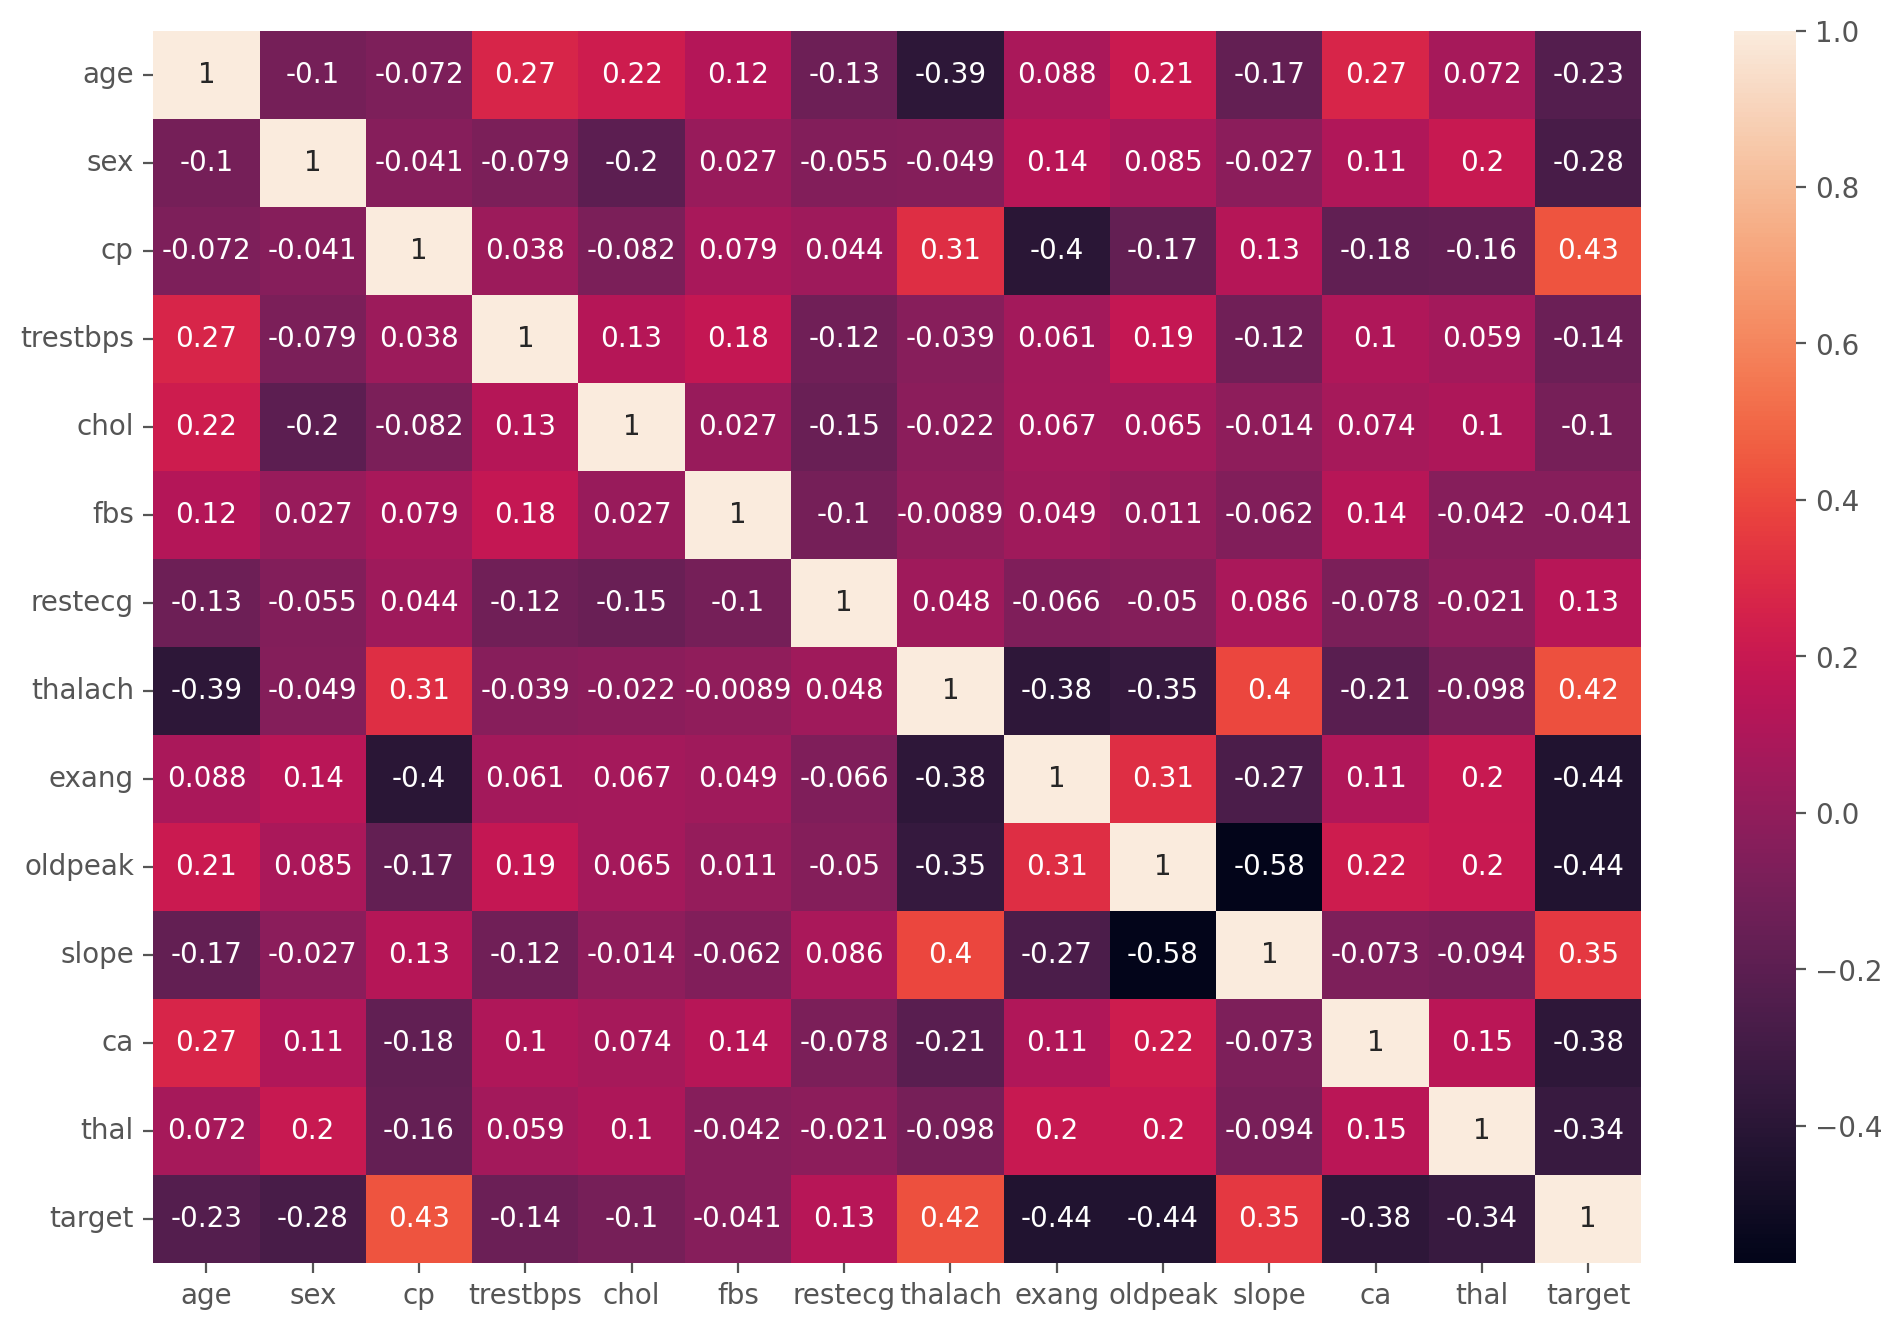

In [24]:
plt.figure(figsize=(12, 8), dpi=200)
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Separación de variables predictoras y variable respuesta

La variable `target` será la variable que queremos predecir. Las demás columnas se usan como variables explicativas.

In [25]:
# División de los datos en train y test
# ==============================================================================
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=1234,
    shuffle=True
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (820, 13)
Tamaño de X_test: (205, 13)
Tamaño de y_train: (820,)
Tamaño de y_test: (205,)


In [26]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [27]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


## Ajuste del modelo logístico múltiple

Se usa `statsmodels` porque permite obtener una tabla de resultados estadísticos del modelo, incluyendo coeficientes, errores estándar, valores z y valores p.

Antes de ajustar el modelo, se agrega una columna constante para representar el intercepto.

In [35]:
# Creación del modelo utilizando matrices como en statsmodels
# ==============================================================================
# A la matriz de predictores se le añade una columna de 1s para el intercepto del modelo.
x_train_const = sm.add_constant(X_train, prepend=True, has_constant='add')
modelo = sm.Logit(endog=y_train, exog=x_train_const)
modelo_fit = modelo.fit()
print(modelo_fit.summary())


Optimization terminated successfully.
         Current function value: 0.359711
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  820
Model:                          Logit   Df Residuals:                      806
Method:                           MLE   Df Model:                           13
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.4807
Time:                        13:06:18   Log-Likelihood:                -294.96
converged:                       True   LL-Null:                       -568.03
Covariance Type:            nonrobust   LLR p-value:                2.280e-108
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5160      1.548      2.272      0.023       0.483       6.549
age            0.0004      0.

In [36]:
# Calcular la pseudo R-cuadrada de McFadden
# ==============================================================================
ll_final = modelo_fit.llf
ll_null = modelo_fit.llnull
pseudo_r2 = 1 - (ll_final / ll_null)

print("Pseudo R-cuadrada de McFadden:", round(pseudo_r2, 4))

Pseudo R-cuadrada de McFadden: 0.4807


## Modelo reducido


In [37]:
# Modelo reducido: selección manual de variables
# ==============================================================================
X_new = df.drop(columns=['target', 'age', 'fbs', 'trestbps', 'chol', 'restecg', 'slope'])
y = df['target']

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new,
    y,
    train_size=0.8,
    random_state=1234,
    shuffle=True
)

X_new_train.head()

,sex,cp,thalach,exang,oldpeak,ca,thal
480,0,0,142,1,1.2,0,3
401,0,0,125,0,1.6,0,2
330,0,2,170,0,0.0,0,2
83,1,2,173,0,0.0,4,2
679,1,2,150,1,1.6,0,3


In [38]:
# Ajuste del modelo reducido
# ==============================================================================
X_new_train_const = sm.add_constant(X_new_train, prepend=True, has_constant='add')
modelo_new = sm.Logit(endog=y_new_train, exog=X_new_train_const)
modelo_new_fit = modelo_new.fit()
print(modelo_new_fit.summary())

Optimization terminated successfully.
         Current function value: 0.378872
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  820
Model:                          Logit   Df Residuals:                      812
Method:                           MLE   Df Model:                            7
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.4531
Time:                        13:07:38   Log-Likelihood:                -310.68
converged:                       True   LL-Null:                       -568.03
Covariance Type:            nonrobust   LLR p-value:                5.515e-107
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8177      0.886      0.922      0.356      -0.920       2.555
sex           -1.3151      0.

## Predicciones

Para predecir con `statsmodels` se debe usar una matriz de prueba con la misma estructura que la matriz usada para entrenar el modelo. Por eso, también se agrega la columna constante a `X_test`.



In [39]:
# Predicciones con intervalo de confianza
# ==============================================================================
X_test_const = sm.add_constant(X_test, prepend=True, has_constant='add')

# Probabilidades estimadas de pertenecer a la clase 1
predicciones = modelo_fit.predict(exog=X_test_const)

# Intervalos de confianza para las probabilidades predichas
predicciones_ic = modelo_fit.get_prediction(exog=X_test_const).summary_frame(alpha=0.05)

# Tabla resumen de predicciones
resultados_prediccion = pd.DataFrame({
    'y_real': y_test.values,
    'probabilidad_clase_1': predicciones.values,
    'IC_95_inf': predicciones_ic['ci_lower'].values,
    'IC_95_sup': predicciones_ic['ci_upper'].values
}, index=X_test.index)

resultados_prediccion.head()

,y_real,probabilidad_clase_1,IC_95_inf,IC_95_sup
836,1,0.905441,0.833333,0.948288
523,0,0.338300,0.217548,0.484568
89,0,0.012344,0.003980,0.037617
915,0,0.296679,0.183493,0.441897
270,1,0.699005,0.569724,0.802881


In [40]:
# Clasificación predicha
# ==============================================================================
umbral = 0.5
clasificacion = np.where(predicciones >= umbral, 1, 0)
clasificacion[:10]

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1])

## Accuracy

Se calcula el porcentaje de aciertos que tiene el modelo al predecir las observaciones de prueba.

In [41]:
# Accuracy de test del modelo
# ==============================================================================
accuracy = accuracy_score(
    y_true=y_test,
    y_pred=clasificacion,
    normalize=True
)

print(f"El accuracy de test es: {100*accuracy:.2f}%")

El accuracy de test es: 85.37%


### Matriz de confusión

In [42]:
# Matriz de confusión de las predicciones de test
# ==============================================================================
cm = pd.crosstab(
    y_test,
    clasificacion,
    rownames=['Real'],
    colnames=['Predicción']
)

cm


Predicción,0,1
Real,,
0,79,22
1,8,96


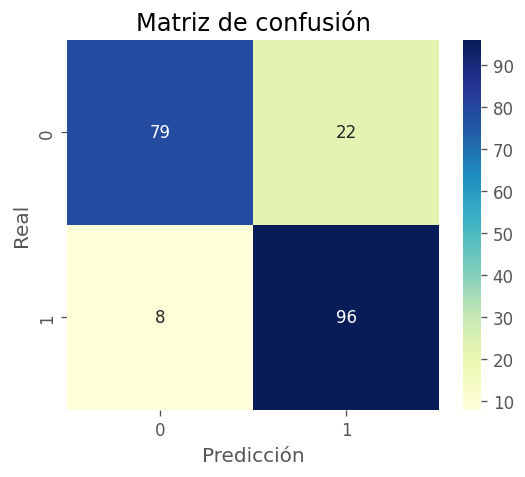

In [43]:
plt.figure(figsize=(5, 4), dpi=120)
sns.heatmap(cm, cmap="YlGnBu", annot=True, fmt='d')
plt.title("Matriz de confusión")
plt.show()

## Métricas recomendadas para evaluar el modelo

Además del *accuracy*, conviene calcular otras métricas porque en problemas de clasificación médica no todos los errores tienen la misma importancia.

En este ejemplo, la variable `target` indica si el paciente presenta o no enfermedad cardíaca:

- `0`: no presenta enfermedad cardíaca.
- `1`: presenta enfermedad cardíaca.

Por esta razón, nos interesa revisar especialmente qué tan bien el modelo identifica a los pacientes con enfermedad cardíaca.

### Interpretación de la matriz de confusión

La matriz de confusión compara la clase real con la clase predicha por el modelo.

| Concepto | Significado |
|---|---|
| Verdadero negativo (TN) | El paciente no tiene enfermedad y el modelo predijo que no tiene enfermedad. |
| Falso positivo (FP) | El paciente no tiene enfermedad, pero el modelo predijo que sí tiene enfermedad. |
| Falso negativo (FN) | El paciente sí tiene enfermedad, pero el modelo predijo que no tiene enfermedad. |
| Verdadero positivo (TP) | El paciente sí tiene enfermedad y el modelo predijo que sí tiene enfermedad. |

En un contexto médico, los falsos negativos suelen ser delicados, porque el modelo estaría dejando pasar pacientes que sí presentan la condición.

In [46]:
# Cálculo de valores de la matriz de confusión
# ==============================================================================
matriz_confusion = confusion_matrix(y_test, clasificacion, labels=[0, 1])
TN, FP, FN, TP = matriz_confusion.ravel()

print("TN - Verdaderos negativos:", TN)
print("FP - Falsos positivos:", FP)
print("FN - Falsos negativos:", FN)
print("TP - Verdaderos positivos:", TP)

TN - Verdaderos negativos: 79
FP - Falsos positivos: 22
FN - Falsos negativos: 8
TP - Verdaderos positivos: 96


### Accuracy, precisión, recall y F1-score

Estas son algunas de las métricas más utilizadas para evaluar modelos de clasificación:

- **Accuracy:** porcentaje total de predicciones correctas.
- **Precisión:** de los pacientes que el modelo predijo con enfermedad, cuántos realmente tenían enfermedad.
- **Recall o sensibilidad:** de los pacientes que realmente tenían enfermedad, cuántos fueron detectados por el modelo.
- **Especificidad:** de los pacientes que realmente no tenían enfermedad, cuántos fueron identificados correctamente.
- **F1-score:** promedio balanceado entre precisión y recall.

Cuando el problema es médico, el **recall** suele ser muy importante, porque mide la capacidad del modelo para detectar los casos positivos.

In [45]:
# Métricas principales de clasificación
# ==============================================================================
accuracy = accuracy_score(y_test, clasificacion)
precision = precision_score(y_test, clasificacion, zero_division=0)
recall = recall_score(y_test, clasificacion, zero_division=0)
f1 = f1_score(y_test, clasificacion, zero_division=0)
especificidad = TN / (TN + FP) if (TN + FP) > 0 else np.nan

print("Accuracy:", round(accuracy, 4))
print("Precisión:", round(precision, 4))
print("Recall o sensibilidad:", round(recall, 4))
print("Especificidad:", round(especificidad, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.8537
Precisión: 0.8136
Recall o sensibilidad: 0.9231
Especificidad: 0.7822
F1-score: 0.8649


### Reporte de clasificación

El reporte de clasificación resume precisión, recall y F1-score para cada clase.

Esto permite revisar si el modelo funciona mejor para una clase que para otra. Por ejemplo, puede ocurrir que el modelo clasifique bien a los pacientes sin enfermedad, pero tenga más dificultad para detectar a los pacientes con enfermedad.

In [47]:
# Reporte completo de clasificación
# ==============================================================================
print(classification_report(
    y_test,
    clasificacion,
    target_names=["Sin enfermedad", "Con enfermedad"],
    zero_division=0
))

                precision    recall  f1-score   support

Sin enfermedad       0.91      0.78      0.84       101
Con enfermedad       0.81      0.92      0.86       104

      accuracy                           0.85       205
     macro avg       0.86      0.85      0.85       205
  weighted avg       0.86      0.85      0.85       205



## Curva ROC

En esta práctica sí es posible aplicar una curva ROC porque la variable respuesta es binaria:

- `0`: no presenta enfermedad cardíaca.
- `1`: presenta enfermedad cardíaca.

La curva ROC evalúa el desempeño del modelo usando diferentes umbrales de clasificación. En lugar de fijar únicamente el umbral en 0.5, analiza qué ocurre si el punto de corte cambia.

La métrica asociada es el **AUC**, que representa el área bajo la curva ROC:

- Un AUC cercano a 0.5 indica que el modelo discrimina de forma similar al azar.
- Un AUC cercano a 1 indica que el modelo separa muy bien las clases.

En regresión logística, la curva ROC se construye usando las probabilidades estimadas por el modelo, no directamente las clases `0` y `1`.

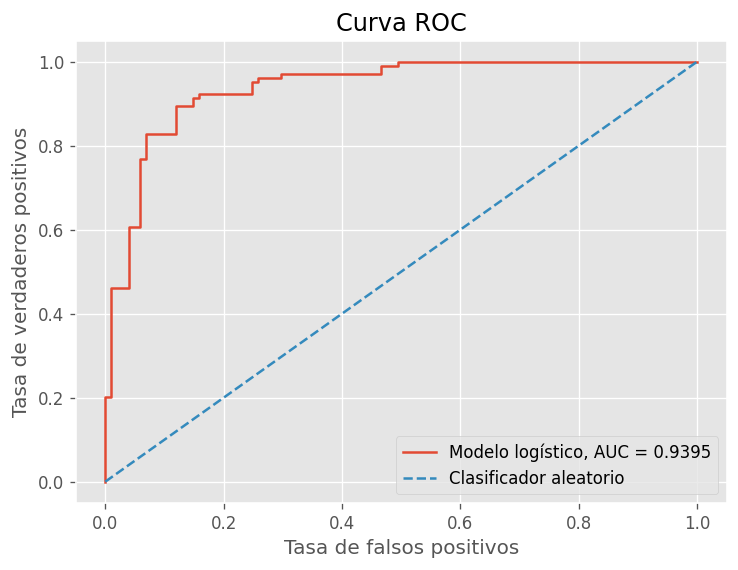

In [48]:
# Curva ROC y AUC
# ==============================================================================
# En este caso, predicciones contiene las probabilidades estimadas de pertenecer a la clase 1.
probabilidades = predicciones

fpr, tpr, thresholds = roc_curve(y_test, probabilidades)
auc = roc_auc_score(y_test, probabilidades)

plt.figure(figsize=(7, 5), dpi=120)
plt.plot(fpr, tpr, label="Modelo logístico, AUC = " + str(round(auc, 4)))
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

### Interpretación de la curva ROC

La curva ROC muestra el intercambio entre detectar correctamente a los pacientes con enfermedad y cometer falsos positivos.

- El eje vertical representa la **sensibilidad** o tasa de verdaderos positivos.
- El eje horizontal representa la tasa de falsos positivos.
- Mientras más cerca esté la curva de la esquina superior izquierda, mejor desempeño tiene el modelo.

Si el AUC obtenido es alto, el modelo tiene buena capacidad para distinguir entre pacientes con y sin enfermedad cardíaca. Si el AUC es bajo, el modelo necesita mejorarse, por ejemplo, revisando variables, escalamiento, selección de predictores o usando otros modelos de clasificación.

## Comparación de métricas e interpretación final

Para cerrar la evaluación del modelo, conviene observar las métricas en conjunto.

No se recomienda decidir únicamente con el accuracy, porque puede ocultar errores importantes. En este ejemplo, además del accuracy, es recomendable revisar:

- **Recall:** para saber cuántos pacientes con enfermedad fueron detectados.
- **F1-score:** para tener una medida balanceada entre precisión y recall.
- **AUC:** para evaluar qué tan bien el modelo separa ambas clases usando probabilidades.

Una posible conclusión debe mencionar si el modelo tiene un desempeño aceptable y qué tipo de error sería más importante reducir en este contexto.

In [49]:
# Resumen de métricas en una tabla
# ==============================================================================
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precisión", "Recall/Sensibilidad", "Especificidad", "F1-score", "AUC"],
    "Valor": [accuracy, precision, recall, especificidad, f1, auc]
})

metricas

,Métrica,Valor
0,Accuracy,0.853659
1,Precisión,0.813559
2,Recall/Sensibilidad,0.923077
3,Especificidad,0.782178
4,F1-score,0.864865
5,AUC,0.939452


## Comparación rápida: modelo completo vs. modelo reducido

Esta comparación ayuda a discutir si conviene usar todas las variables o un conjunto más pequeño de predictores. Un modelo más simple puede ser más fácil de interpretar, pero no siempre mejora el desempeño.

In [50]:
# Predicción del modelo reducido
# ==============================================================================
X_new_test_const = sm.add_constant(X_new_test, prepend=True, has_constant='add')
predicciones_new = modelo_new_fit.predict(exog=X_new_test_const)
clasificacion_new = np.where(predicciones_new >= 0.5, 1, 0)

accuracy_new = accuracy_score(y_new_test, clasificacion_new)
precision_new = precision_score(y_new_test, clasificacion_new, zero_division=0)
recall_new = recall_score(y_new_test, clasificacion_new, zero_division=0)
f1_new = f1_score(y_new_test, clasificacion_new, zero_division=0)
auc_new = roc_auc_score(y_new_test, predicciones_new)

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Completo", "Reducido"],
    "Accuracy": [accuracy, accuracy_new],
    "Precisión": [precision, precision_new],
    "Recall": [recall, recall_new],
    "F1-score": [f1, f1_new],
    "AUC": [auc, auc_new]
})

comparacion_modelos

,Modelo,Accuracy,Precisión,Recall,F1-score,AUC
0,Completo,0.853659,0.813559,0.923077,0.864865,0.939452
1,Reducido,0.843902,0.815789,0.894231,0.853211,0.921363


## Actividad para el estudiante

Responde las siguientes preguntas con base en los resultados obtenidos:

1. ¿Cuál fue el valor del accuracy del modelo completo?
# fue de 0.8537 o 85.37%
2. ¿Cuál fue el valor del recall o sensibilidad?
#fue de 0.9231 o 92.31%
3. ¿Por qué el recall puede ser importante en este problema?
# porque permite identificar correctamente a la mayoría de los pacientes que sí tienen enfermedad cardíaca, reduciendo los falsos negativos
4. ¿El modelo comete más falsos positivos o falsos negativos?
#comete más falsos positivos que son 22 que falsos negativos que son de 8.
5. ¿Qué indica el valor del AUC?
#mide la capacidad del modelo para distinguir entre pacientes con y sin enfermedad
6. ¿Qué modelo tiene mejor desempeño: el modelo completo o el modelo reducido?
#el modelo completo tiene un mejor desempeño porque presenta valores ligeramente superiores de Accuracy
7. ¿Consideras que el modelo es adecuado para apoyar la detección de enfermedad cardíaca? Justifica tu respuesta.
#si el modelo es adecuado para apoyar la deteccion de enfermedad cardiaca, ya que presenta un accuracy de 85.37%, un recall de 92.31% y un AUC de 0.9395, lo que indica un bueno para clasificar

**Nota:** La regresión logística puede apoyar el análisis, pero no sustituye el diagnóstico médico. Sus resultados deben interpretarse como una herramienta estadística de clasificación.